In [1]:
import numpy as np
import os

from maui_analysis.process_behavior import pull_fictrac_speed, pull_fictrac_timestamps, save_speed_data
from maui_analysis.data_alignment import *
from maui_codebook.visualizations import *
import xarray as xr
import glob

In [2]:
fly = '09'
win = '1'

In [3]:
path_to_voltage_csv = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/')[0]
voltage_csv = glob.glob(path_to_voltage_csv + '*VoltageRecording_001.csv')[0]
dat_file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10_GC8m_fly{fly}_win0{win}_trial01/*.dat')[0]
print(voltage_csv)
processed_path = '/Volumes/AhmedLab/princess/data/pIP10/processed'
experiment_path = glob.glob(processed_path + f'/pIP10_TSeries_*fly{fly}_win0{win}*')[0]

SLICES = 11
DIMENSIONS = [512,512,11]

/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001_Cycle00001_VoltageRecording_001.csv


Fly02Win01
- rois = [ [6,8], [6,14], [6,11], [6,19], [7,2], [7,10], [8,9],  [8,14], [9,6]]
Fly03Win01
- rois = [ [4,4], [4,16], [5,18], [6,1],  [7,4]]
Fly03Win02
- rois =
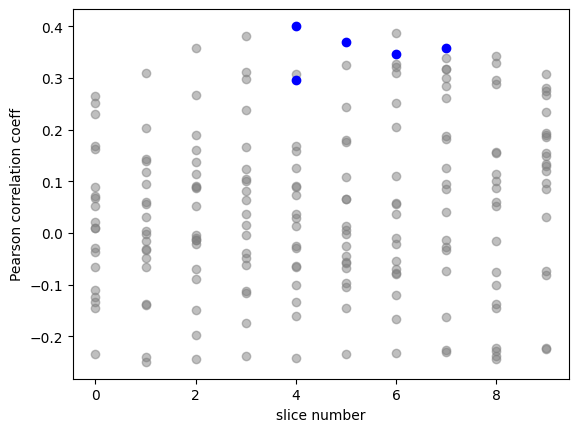

In [4]:

hf_path = f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/synced_data.h5'
if not glob.glob(hf_path):
    save_path = glob.glob(os.path.dirname(hf_path))[0]
    save_speed_data(dat_file, voltage_csv, save_path=save_path)
    # # takes ~2-3 minutes
synced_data_hf = glob.glob(hf_path)[0]


In [5]:
# process fictrac data
beh_speed = pull_fictrac_speed(dat_file)
beh_timestamps = pull_fictrac_timestamps(voltage_csv, beh_speed)

# align to scope data
maui_vol_timestamps = align_scopetimes_to_behaviortimes(path_to_voltage_csv, synced_data_hf, SLICES)
walk_times, walk_speeds = open_processed_behavior_data(synced_data_hf)
# takes Xx minutes

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


In [6]:
from scipy.interpolate import interp1d
def interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps):
    f = interp1d(walk_times, walk_speeds)
    speed_new = f(maui_vol_timestamps)
    return speed_new

In [7]:
synced_walk_speeds = interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps)

In [10]:
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]
with h5py.File(file, "r") as f:
    print(f.keys())
    cluster_labels = f["labels"][...]
    signal = f["signals"][...]

signal = signal[...,:len(maui_vol_timestamps)]


signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)

behav_xr = xr.DataArray(
    data = synced_walk_speeds,
    dims = ['time'],
    coords = {'time': maui_vol_timestamps/1000}
)

<KeysViewHDF5 ['labels', 'signals']>


In [11]:
def plot_zscored_activity(clusters_toplot, signal_xarray):
    fig, ax = plt.subplots(figsize=(20, len(clusters_toplot)))
    yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

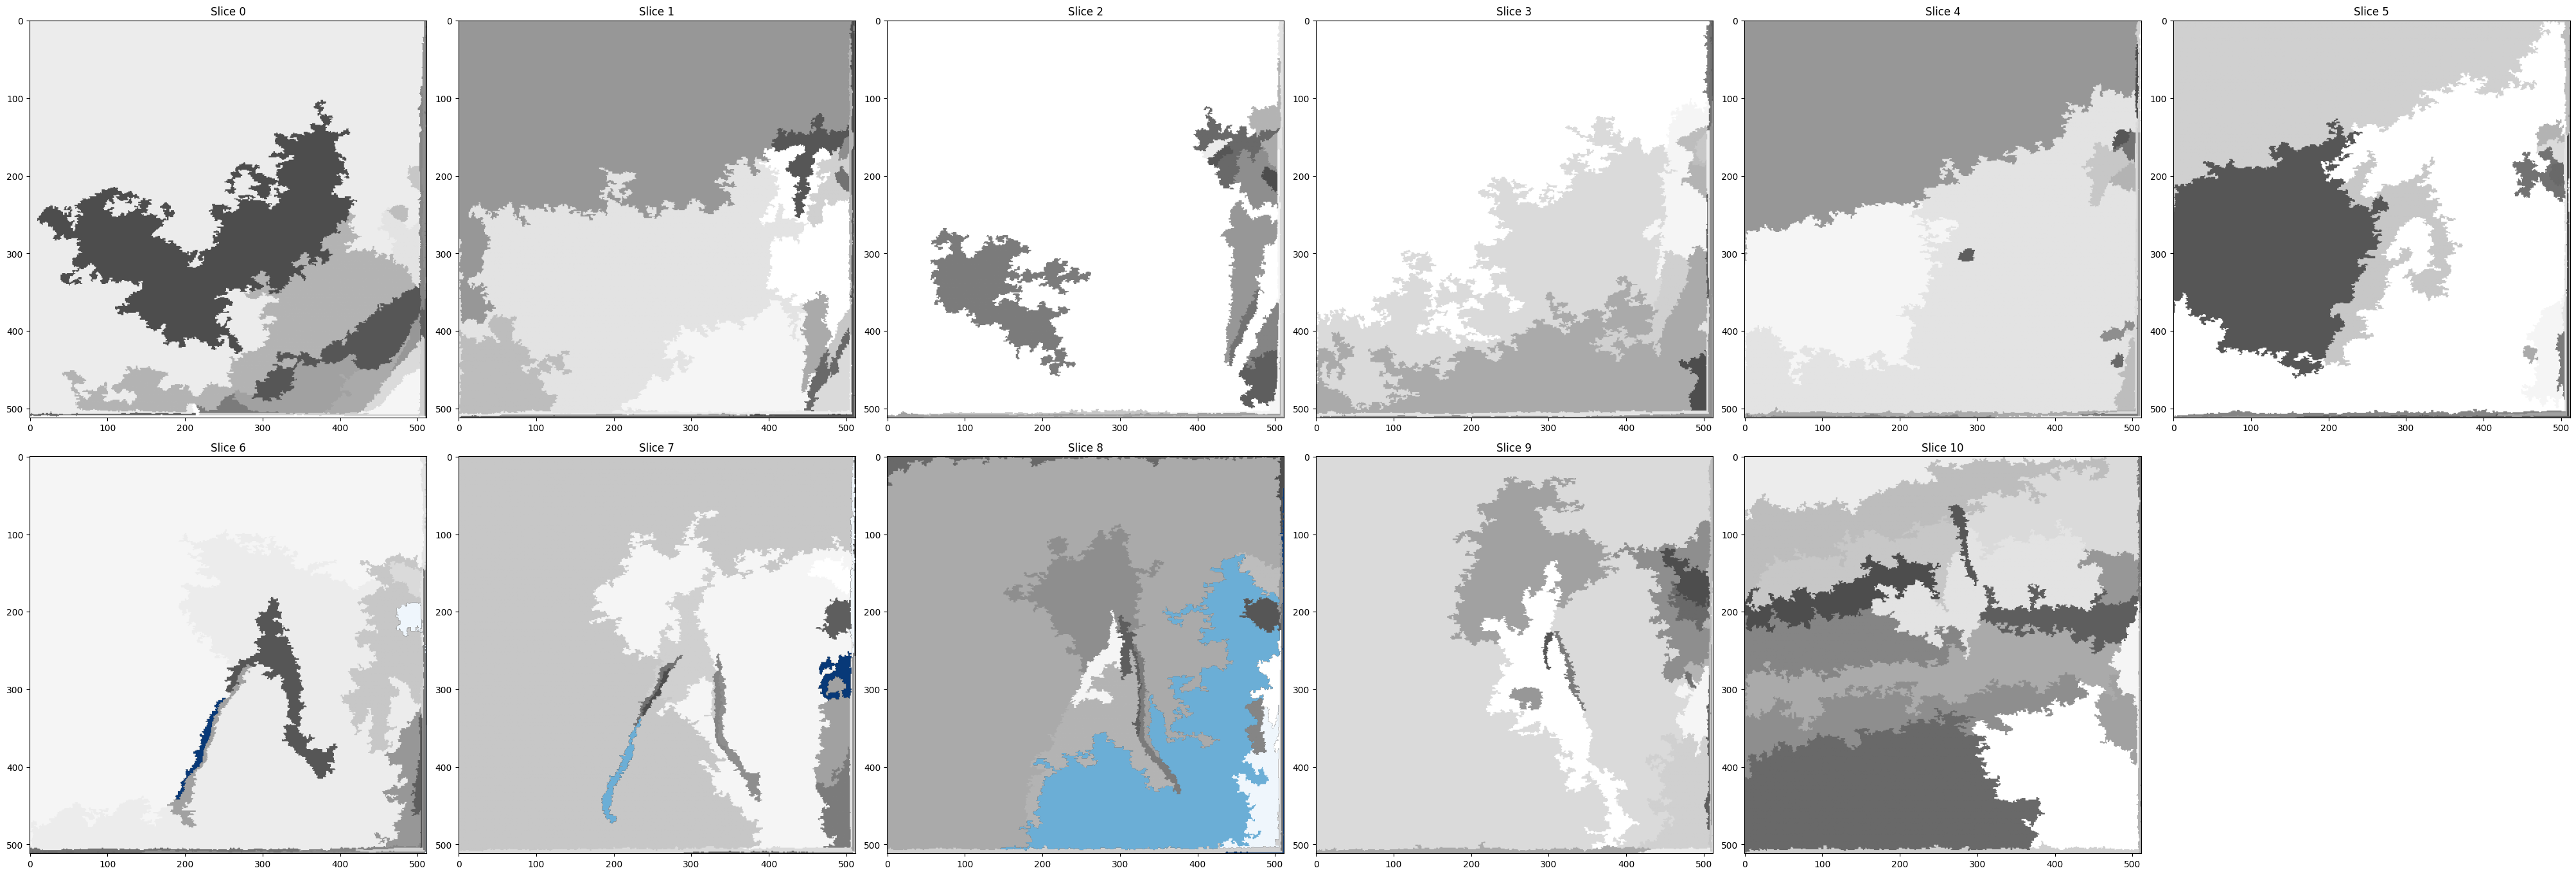

In [23]:
rois = [[6,0], [6,11], [6,12], [7,9], [7,11], [7,10],[8,5], [8,3], [8,4] ]
# rois = [4,4], [4,16], [5,18]
# fig = plot_zscored_activity(rois, signal_xr)
# plt.figure(figsize=(20, 3))
# plt.plot(maui_vol_timestamps/1000,synced_walk_speeds, color = 'k')
fig2 = plot_spatial_location(rois, cluster_labels, DIMENSIONS)

In [26]:
signal_xr.d

('zposs', 'roi', 'time')

In [41]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc
to_cluster = signal_xr.stack(cluster=['zposs','roi'])
Z = shc.linkage(to_cluster, method='ward')
# clustered_rois = AgglomerativeClustering(n_clusters=5,  linkage='ward').fit(to_cluster.sel())
NCLUSTERS = 50
dn = shc.dendrogram(Z, p=NCLUSTERS, truncate_mode='lastp', no_plot=True)
clust_labels = shc.fcluster(Z, NCLUSTERS, criterion='maxclust')

dn

{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [5.0, 5.0, 23.75, 23.75],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [65.0, 65.0, 82.5, 82.5],
  [105.0, 105.0, 115.0, 115.0],
  [73.75, 73.75, 110.0, 110.0],
  [55.0, 55.0, 91.875, 91.875],
  [14.375, 14.375, 73.4375, 73.4375],
  [125.0, 125.0, 135.0, 135.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [175.0, 175.0, 185.0, 185.0],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [180.0, 180.0, 202.5, 202.5],
  [152.5, 152.5, 191.25, 191.25],
  [130.0, 130.0, 171.875, 171.875],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [225.0, 225.0, 242.5, 242.5],
  [275.0, 275.0, 285.0, 285.0],
  [265.0, 265.0, 280.0, 280.0],
  [295.0, 295.0, 305.0, 305.0],
  [325.0, 325.0, 335.0, 335.0],
  [315.0, 315.0, 330.0, 330.0],
  [300.0, 300.0, 322.5, 322.5],
  [272.5, 272.5, 311.25, 311.25],
  [233.75, 233.75, 291.875, 291.875],
  [345

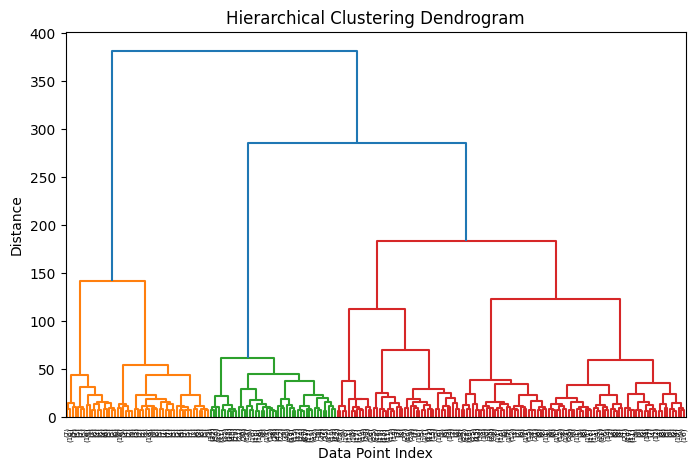

In [46]:
# Create the figure
plt.figure(figsize=(8, 5))

# Draw the tree
shc.dendrogram(Z, p=220, truncate_mode='lastp')

# Add annotations
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Point Index")
plt.ylabel("Distance")

# Render image
plt.show()


In [43]:
# merge with original dataset
clust_time_ser = to_cluster.copy()
clust_time_ser['cluster'] = clust_labels

/var/folders/6j/4hb4hfhs6ygdhcvnvsxhm5yr0000gs/T/ipykernel_62126/2719624516.py:3: FutureWarning: updating coordinate 'cluster', which is a PandasMultiIndex, would leave the multi-index level coordinates ['zposs', 'roi'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['cluster', 'zposs', 'roi'])` to drop the coordinates' values before assigning new coordinate values.
  clust_time_ser['cluster'] = clust_labels


CoordinateValidationError: conflicting sizes for dimension 'cluster': length 220 on the data but length 2778 on coordinate 'cluster'

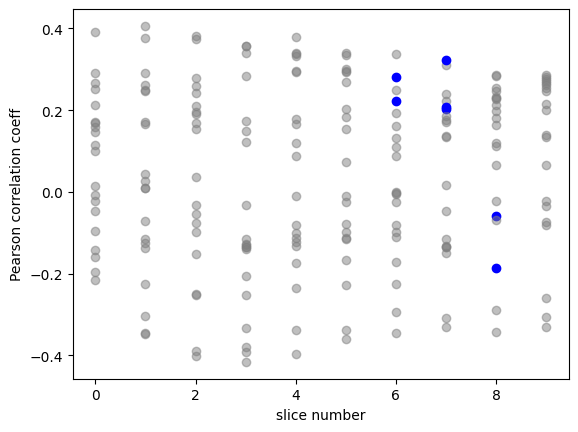

In [14]:
# plot where x is z-poss, y is correlation
correlation = xr.corr(signal_xr, behav_xr, dim='time')

for iSlice in range(signal_xr['zposs'].max().values):
    # print(iSlice)
    to_plot = correlation.isel(zposs=iSlice)
    for i, corrs in enumerate(to_plot):

        if [iSlice, i] in rois:
            # plot pIP10 supervoxels in blue
            iCorr = correlation.isel(zposs=iSlice, roi=i)
            plt.scatter(iSlice, iCorr, color='b')
        else:
            # plot non-pIP10 supervoxels in gray
            plt.scatter(iSlice, corrs, color='gray', alpha=0.5)
        plt.xlabel('slice number')
        plt.ylabel('Pearson correlation coeff')
        # to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])

In [15]:
# making control rois
